<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo11classify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# YOLO로 이미지 분류 모델 작성
# YOLO 기반 이미지 분류 모델(예:YOLO-cls)은 이미지 속 특정 객체의 위치를 찾는 대신,
# 입력된 전체 이미지가 어떤 클래스(카테고리)에 속하는지 판별하고 해당 확률(Confidence Score)을 출력

# flower dataset 사용

!pip install ultralytics opencv-python

In [9]:
import random
import shutil
from pathlib import Path
import tensorflow as tf
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dataset_path = tf.keras.utils.get_file(
    fname="flower_photos",
    origin="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz",
    untar=True
)

# 다운로드 된 위치
SOURCE_DIR = Path(dataset_path) / "flower_photos"
print(('SOURCE_DIR =', SOURCE_DIR))

# 클래스 목록 보기
classes = [p.name for p in SOURCE_DIR.iterdir() if p.is_dir()]
print('classes :', classes)

('SOURCE_DIR =', PosixPath('/root/.keras/datasets/flower_photos/flower_photos'))
classes : ['dandelion', 'tulips', 'roses', 'daisy', 'sunflowers']


In [10]:
# YOLO 학습용 dataset 폴더 생성
DATASET_DIR = Path("flower_dataset")

if DATASET_DIR.exists():
  shutil.rmtree(DATASET_DIR)

# train / val / test 폴더 생성
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

for class_dir in SOURCE_DIR.iterdir():
  if not class_dir.is_dir():    # 폴더가 아니면 skip
    continue

  class_name = class_dir.name   # 클래스 이름 저장(ex:daisy ...)
  images = list(class_dir.glob("*.*"))  # 모든 이미지 파일 가져오기

  if len(images) == 0:
    continue

  random.shuffle(images)  # 학습 편향 방지를 목적으로 데이터 섞기

  total = len(images)
  # print("total :", total)
  train_end = int(total * 0.7)
  val_end = int(total * 0.9)

  # 데이터 분할 (7:2:1)
  splits = {
      "train" : images[:train_end],
      "val" : images[train_end:val_end],
      "test" : images[val_end:]
  }
  print(len(splits["train"]), " ", len(splits["val"]), " ", len(splits["test"]))

  # 분할된 이미지를 각 폴더에 복사
  for split_name, split_images in splits.items():
    split_dir = DATASET_DIR / split_name / class_name
    split_dir.mkdir(parents=True, exist_ok=True)

    for image in split_images:
      shutil.copy(image,  split_dir/image.name) # 파일 복사

# dataset 확인 (정상 생성 여부 확인)
for split in ['train', 'val', 'test']:
  print(f'[{split}]')
  for class_dir in (DATASET_DIR / split).iterdir():   # 클래스별 폴더 탐색
    count = len(list(class_dir.glob("*.*")))
    print(f'  {class_dir.name} : {count}')

628   180   90
559   160   80
448   128   65
443   126   64
489   140   70
[train]
  dandelion : 628
  tulips : 559
  roses : 448
  daisy : 443
  sunflowers : 489
[val]
  dandelion : 180
  tulips : 160
  roses : 128
  daisy : 126
  sunflowers : 140
[test]
  dandelion : 90
  tulips : 80
  roses : 65
  daisy : 64
  sunflowers : 70


In [11]:
# YOLO11 분류 모델을 재학습 (train + val 사용)
model = YOLO('yolo11n-cls.pt')  # 사전 학습된 YOLO 11 calssification 모델(80개의 클래스로 분류) 로딩

model.train(
    data = str(DATASET_DIR.resolve()), # 경로는 반드시 절대경로
    epochs = 5,
    imgsz = 224,
    batch = 16,
    device = 'cpu'
)

print('학습 완료')

Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/flower_dataset, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

test acc : 97.02%
              precision    recall  f1-score   support

       daisy       1.00      0.97      0.98        64
   dandelion       0.98      1.00      0.99        90
       roses       0.93      0.97      0.95        65
  sunflowers       0.99      0.96      0.97        70
      tulips       0.96      0.95      0.96        80

    accuracy                           0.97       369
   macro avg       0.97      0.97      0.97       369
weighted avg       0.97      0.97      0.97       369



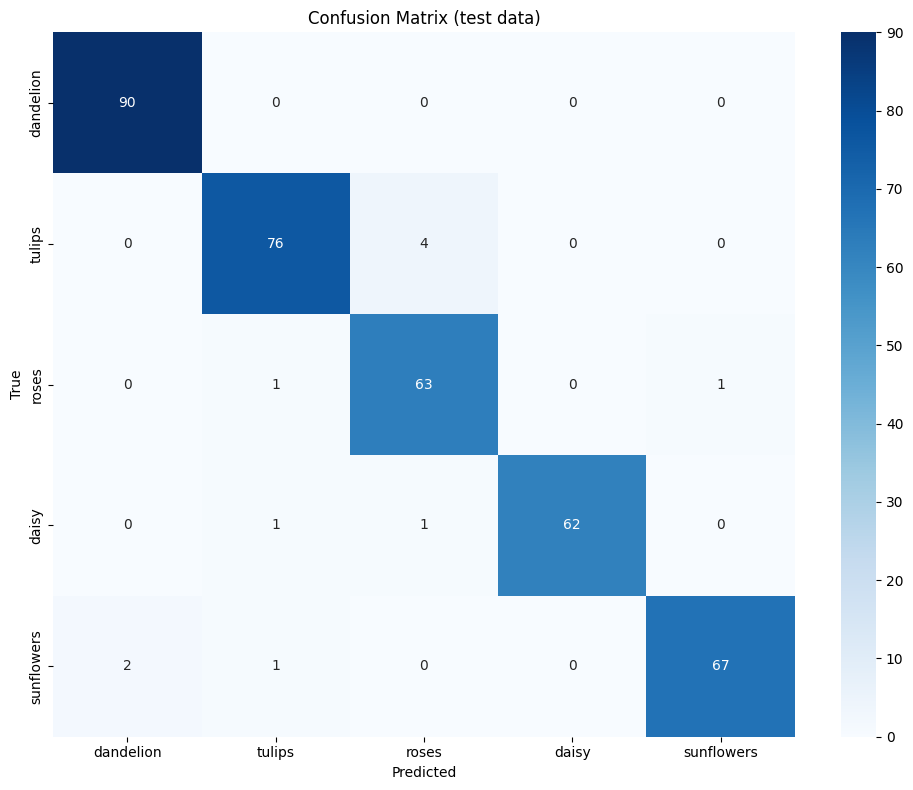

In [14]:
# 모델 성능 측정 - 가장 좋은 모델 로딩
best_model = YOLO("runs/classify/train/weights/best.pt")

y_true = []   # 실제 정답
y_pred = []   # 예측 정답

test_dir = DATASET_DIR / "test"

for class_dir in test_dir.iterdir():
  true_label = class_dir.name

  for image_path in class_dir.glob("*.*"):
    results = best_model.predict(   # 예측 수행
      source=str(image_path), imgsz=224, verbose=False
    )

    r = results[0]
    pred_idx = r.probs.top1   # 가장 높은 확률 클래스의 인덱스
    pred_label = r.names[pred_idx]   # 가장 높은 확률 클래스의 이름
    y_true.append(true_label)
    y_pred.append(pred_label) # Changed from pred_idx to pred_label

# 성능 출력
acc = accuracy_score(y_true, y_pred)
print(f'test acc : {acc * 100:.2f}%')

print(classification_report(y_true, y_pred))

# hitmap으로 혼동행렬 시각화
cm = confusion_matrix(y_true, y_pred, labels=classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
  cm, annot=True, fmt='d',
  xticklabels=classes,
  yticklabels=classes,
  cmap='Blues'
)
plt.title('Confusion Matrix (test data)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('yolo11cm.png')
plt.show()

In [16]:
print("새 꽃 이미지 분류")
sample_path = Path("myflower.jpg")

if sample_path.exists:
  results = best_model.predict(
    source=str(sample_path), imgsz=224, verbose=False
  )
  r = results[0]
  pred_idx = r.probs.top1
  pred_label = r.names[pred_idx]
  confidence = float(r.probs.top1conf)  # 신뢰도

  print(sample_path)
  print(f'예측 : {pred_label}')
  print(f'신뢰도 : {round(confidence, 3)}')
else:
  print('file 없음')

새 꽃 이미지 분류
myflower.jpg
예측 : roses
신뢰도 : 1.0
